defino función PDB a 3di

In [4]:
def pdbid_to_3di_single_chain(pdb_id, chain_id):
    
    #hay que especificar la
    import tempfile
    import os
    import requests
    import subprocess

    # Ruta al ejecutable de foldseek
    foldseek_path = os.path.expanduser("~/Desktop/TFG/bin/foldseek/bin/foldseek")

    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    with tempfile.TemporaryDirectory() as tmpdir:
        out_file = os.path.join(tmpdir, f"{pdb_id}.pdb")
        filtered_file = os.path.join(tmpdir, f"{pdb_id}_{chain_id}.pdb")
        output_3di = os.path.join(tmpdir, f"{pdb_id}_{chain_id}.3di")
        
        response = requests.get(url)
        if response.status_code == 200:
            # Descargar PDB completo
            with open(out_file, "w") as f:
                f.write(response.text)
            
            # Filtrar solo la cadena que quieres (por la columna 21 del PDB)
            with open(out_file, "r") as f:
                lines = f.readlines()
            
            filtered_lines = []
            for line in lines:
                # Mantener headers y líneas ATOM/HETATM de la cadena especificada
                if line.startswith(("HEADER", "TITLE", "REMARK", "ATOM", "HETATM", "TER", "END")):
                    if line.startswith("ATOM") or line.startswith("HETATM"):
                        if len(line) > 21 and line[21:22] == chain_id:
                            filtered_lines.append(line)
                    else:
                        filtered_lines.append(line)
            
            with open(filtered_file, "w") as f:
                f.writelines(filtered_lines)
            
            # Ejecutar Foldseek con el PDB filtrado usando la ruta completa
            cmd = [foldseek_path, "structureto3didescriptor", filtered_file, output_3di]
            subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            
            if os.path.exists(output_3di):
                with open(output_3di, "r") as f:
                    lines = f.readlines()
                
                solo_3di = [line.split('\t')[2].strip() for line in lines if line.strip()]
                return solo_3di
            else:
                print(f"Error: No se generó el archivo .3di para {pdb_id} cadena {chain_id}")
                return None
        else:
            print(f"Error fetching data for PDB ID {pdb_id}: {response.status_code}")
            return None

# Ejemplo de uso:
print("3Di para 1A8M cadena A:")
print(pdbid_to_3di_single_chain("1A8M", "A"))


3Di para 1A8M cadena A:
['DDDDPWFKFKWFADPPDDWFGATHQPPDPTDGDDQWDCPPNWTFDRFWAKKKKKKKFKFKDFFDDDQWDKKKKFKWKQAPVNRDTDTDDMDIDIPRNSCRPPPRGRHMDMDMDMDIDIDTGGGRMIMHITIDTSVRTDDVDDPHTMIMMIGD']


In [6]:
import pandas as pd

df = pd.read_csv("Uniprot_PDB_Chain_GOA.csv")

for index, row in df.iterrows():
    pdb_id = row["pdb_id"]
    chain_id = row["chain_id"]
    print(f"Procesando {pdb_id} cadena {chain_id}...")
    three_di = pdbid_to_3di_single_chain(pdb_id, chain_id)
    df.at[index, "3di"] = ";".join(three_di) if three_di else None

df.to_csv("pdb_3di.csv", index=False)

Procesando 8QTC cadena A...
Procesando 8QT5 cadena A...
Procesando 2BQ0 cadena A...
Procesando 5WFU cadena A...
Procesando 2BR9 cadena A...
Procesando 2C63 cadena A...
Procesando 5YQG cadena A...
Procesando 2B05 cadena A...
Procesando 4F7R cadena A...
Procesando 1YWT cadena A...
Procesando 2BTP cadena A...
Procesando 1IB1 cadena A...
Procesando 7EXE cadena A...
Procesando 7DLW cadena A...
Procesando 1B8G cadena A...
Procesando 2JAK cadena A...
Procesando 1B3U cadena A...
Procesando 2PF4 cadena A...
Procesando 9MF5 cadena A...
Procesando 7E37 cadena A...
Procesando 2YB1 cadena A...
Procesando 2CR4 cadena A...
Procesando 6IXE cadena A...
Procesando 8GQA cadena B...
Procesando 2QNK cadena A...
Procesando 1ZVF cadena A...
Procesando 2GF2 cadena A...
Procesando 7ULQ cadena A...
Procesando 3USS cadena A...
Procesando 1LMZ cadena A...
Procesando 1DIZ cadena A...
Procesando 1BNK cadena A...
Procesando 2H7Z cadena A...
Procesando 5A60 cadena A...
Procesando 2FBL cadena A...
Procesando 6RC7 cade

In [9]:
import torch
import numpy as np
import json
from transformers import T5Tokenizer, T5EncoderModel, AutoConfig

# ==========================================
# 1. Model Loading (Optimized for 24GB GPU)
# ==========================================
device = "cuda:0" if torch.cuda.is_available() else "cpu"

def load_prostt5_model(model_path="Rostlab/ProstT5"):
    tokenizer = T5Tokenizer.from_pretrained(model_path)
    model = T5EncoderModel.from_pretrained(model_path)
    model = model.to(device).half().eval()
    return model, tokenizer

# ==========================================
# 2. Embedding Function
# ==========================================
def generate_3di_embedding(model, tokenizer, seq_3di):
    # ProstT5 requires spaces between tokens and a <3di> prefix
    formatted_seq = "<3di> " + " ".join(list(seq_3di))
    
    inputs = tokenizer(formatted_seq, return_tensors="pt").to(device)
    
    with torch.no_grad():
        output = model(**inputs)
    
    # Move to CPU, convert to float32, and pool (Mean)
    return output.last_hidden_state[0].mean(dim=0).detach().cpu().float().numpy()


In [10]:
m,t = load_prostt5_model()
generate_3di_embedding(m,t,"DCPVVVDDD")


Loading weights: 100%|██████████| 195/195 [00:00<00:00, 2439.62it/s, Materializing param=shared.weight]                                                     


array([-0.08172607, -0.00814819,  0.05966187, ...,  0.22766113,
        0.0229187 ,  0.0171051 ], shape=(1024,), dtype=float32)

In [11]:
input_file = "pdb_3di.csv"
output_file = "BioData_Structure_embeddings.csv"

df = pd.read_csv(input_file, sep=',')
m,t = load_prostt5_model()
print(f"Starting embedding generation for {len(df)} rows...")

for index, row in df.iterrows():
    # Progress indicator
    if index % 10 == 0:
        print(f"Processing row {index}/{len(df)}...")

    seq_3di = row.get("3di")
    if pd.notna(seq_3di) and seq_3di != "":
        seq_3di = str(seq_3di).split(";")[0]
    
    if pd.notna(seq_3di) and seq_3di != "":
        try:
            vec = generate_3di_embedding(m,t,str(seq_3di))
            # Store as a JSON string to keep the CSV readable
            df.at[index, "embeddings"] = json.dumps(vec.tolist())
        except Exception as e:
            print(f"Error at index {index}, col {i}: {e}")

# Save the final result
df.to_csv(output_file, sep=';', index=False)
print(f"Done! Saved to {output_file}")

Loading weights: 100%|██████████| 195/195 [00:00<00:00, 2602.56it/s, Materializing param=shared.weight]                                                     


Starting embedding generation for 18135 rows...
Processing row 0/18135...
Processing row 10/18135...
Processing row 20/18135...
Processing row 30/18135...
Processing row 40/18135...
Processing row 50/18135...
Processing row 60/18135...
Processing row 70/18135...
Processing row 80/18135...
Processing row 90/18135...
Processing row 100/18135...
Processing row 110/18135...
Processing row 120/18135...
Processing row 130/18135...
Processing row 140/18135...
Processing row 150/18135...
Processing row 160/18135...
Processing row 170/18135...
Processing row 180/18135...
Processing row 190/18135...
Processing row 200/18135...
Processing row 210/18135...
Processing row 220/18135...
Processing row 230/18135...
Processing row 240/18135...
Processing row 250/18135...
Processing row 260/18135...
Processing row 270/18135...
Processing row 280/18135...
Processing row 290/18135...
Processing row 300/18135...
Processing row 310/18135...
Processing row 320/18135...
Processing row 330/18135...
Processing 

Aquí calculamos los K nearest neighbours

In [7]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import ast
import time
from pathlib import Path

class CalculadorVecinosCercanos:
    """Calcula los k vecinos mas cercanos para cada accesion."""

    def __init__(self, archivo_entrada, distancia_metrica='cosine', k=10):
        """
        Parameters
        ----------
        archivo_entrada : str
            Ruta al CSV de entrada
        distancia_metrica : str
            'cosine' o 'euclidean'
        k : int
            Numero de vecinos a retornar
        """
        self.archivo_entrada = archivo_entrada
        self.distancia_metrica = distancia_metrica
        self.k = k
        self.df = None
        self.embeddings = None
        self.distancias = None
        self.resultados_df = None
        self.columna_embedding = None

    def cargar_datos(self, columna_embedding):
        """Cargar CSV y extraer embeddings validos."""
        print(f"Cargando {self.archivo_entrada}...")

        self.columna_embedding = columna_embedding

        # Intentar detectar el separador de forma robusta.
        self.df = pd.read_csv(self.archivo_entrada, sep=None, engine='python')

        if columna_embedding not in self.df.columns:
            for sep in [',', ';', '\t']:
                df_try = pd.read_csv(self.archivo_entrada, sep=sep)
                if columna_embedding in df_try.columns:
                    self.df = df_try
                    break

        print(f"   OK: {len(self.df)} filas cargadas")
        print(f"   Columnas: {list(self.df.columns)}")

        if columna_embedding not in self.df.columns:
            raise ValueError(f"No existe la columna '{columna_embedding}' en el CSV.")

        # Extraer embeddings y filtrar filas invalidas o con dimension inconsistente
        self.embeddings = self._extraer_embeddings()

        print(f"   OK: embeddings extraidos: shape={self.embeddings.shape}")
        print(f"   Filas utiles tras limpieza: {len(self.df)}")
        return self

    def _parse_embedding(self, emb):
        """Convierte una celda de embedding a np.ndarray 1D de float32."""
        if emb is None:
            return None

        # NaN de pandas/numpy
        try:
            if pd.isna(emb):
                return None
        except Exception:
            pass

        if isinstance(emb, str):
            txt = emb.strip()
            if not txt:
                return None

            if txt.startswith('[') and txt.endswith(']'):
                # Formato lista: "[0.1, 0.2, ...]"
                values = ast.literal_eval(txt)
                arr = np.asarray(values, dtype=np.float32)
            else:
                # Fallback: separado por espacios o comas
                tokens = txt.replace(',', ' ').split()
                arr = np.asarray([float(x) for x in tokens], dtype=np.float32)
        else:
            arr = np.asarray(emb, dtype=np.float32)

        # Asegurar vector 1D
        arr = np.ravel(arr).astype(np.float32)
        if arr.size == 0:
            return None
        return arr

    def _extraer_embeddings(self):
        """Extrae embeddings validos y mantiene solo filas con misma dimension."""
        embeddings_list = []
        indices_validos = []
        dimension_esperada = None
        filas_vacias = 0
        filas_invalidas = 0
        filas_dimension_distinta = 0

        for idx, emb in enumerate(self.df[self.columna_embedding]):
            try:
                emb_array = self._parse_embedding(emb)
            except Exception as e:
                filas_invalidas += 1
                print(f"   Aviso: fila {idx} invalida ({type(e).__name__}: {e})")
                continue

            if emb_array is None:
                filas_vacias += 1
                continue

            if dimension_esperada is None:
                dimension_esperada = emb_array.shape[0]

            if emb_array.shape[0] != dimension_esperada:
                filas_dimension_distinta += 1
                continue

            embeddings_list.append(emb_array)
            indices_validos.append(idx)

        if not embeddings_list:
            raise ValueError(
                "No se encontraron embeddings validos con una dimension consistente."
            )

        # Mantener df alineado con la matriz de embeddings
        self.df = self.df.iloc[indices_validos].reset_index(drop=True)

        print("\nResumen limpieza embeddings:")
        print(f"   - Filas vacias/NaN: {filas_vacias}")
        print(f"   - Filas invalidas: {filas_invalidas}")
        print(f"   - Filas con dimension distinta: {filas_dimension_distinta}")
        print(f"   - Dimension usada: {dimension_esperada}")

        return np.vstack(embeddings_list).astype(np.float32)

    def calcular_distancias(self):
        """Calcular matriz de distancias."""
        print(f"\nCalculando distancias ({self.distancia_metrica})...")
        t_start = time.perf_counter()

        # Calcular matriz de distancias
        self.distancias = cdist(self.embeddings, self.embeddings, metric=self.distancia_metrica)

        elapsed = time.perf_counter() - t_start
        print(f"   OK: matriz calculada en {elapsed:.2f}s")
        print(f"   Shape: {self.distancias.shape}")

        return self

    def encontrar_vecinos(self):
        """Encontrar k vecinos mas cercanos para cada accesion."""
        print(f"\nBuscando los {self.k} vecinos mas cercanos para cada accesion...")

        resultados = []
        n_accesiones = len(self.df)

        for i in range(n_accesiones):
            # Mostrar progreso
            if (i + 1) % max(1, n_accesiones // 10) == 0:
                print(f"   Procesadas {i + 1}/{n_accesiones} accesiones...")

            # Obtener distancias para esta accesion
            distancias_i = self.distancias[i]

            # Ordenar por distancia (ascendente)
            indices_ordenados = np.argsort(distancias_i)

            # Tomar los top-k excluyendo la misma accesion (indice i)
            top_k_indices = []
            for idx in indices_ordenados:
                if idx != i and len(top_k_indices) < self.k:
                    top_k_indices.append(idx)

            # Crear registros de resultados
            accession_query = self.df.iloc[i]['accession']
            uniprot_query = self.df.iloc[i]['uniprot_id']

            for rank, idx_neighbor in enumerate(top_k_indices, start=1):
                fila_neighbor = self.df.iloc[idx_neighbor]

                resultados.append({
                    'accession': accession_query,
                    'uniprot_id': uniprot_query,
                    'pdb_id': self.df.iloc[i].get('pdb_id', ''),
                    'chain_id': self.df.iloc[i].get('chain_id', ''),
                    'neighbor_accession': fila_neighbor['accession'],
                    'neighbor_uniprot_id': fila_neighbor['uniprot_id'],
                    'neighbor_pdb_id': fila_neighbor.get('pdb_id', ''),
                    'neighbor_chain_id': fila_neighbor.get('chain_id', ''),
                    'distance': float(distancias_i[idx_neighbor]),
                    'rank': rank
                })

        self.resultados_df = pd.DataFrame(resultados)
        print(f"   OK: {len(self.resultados_df)} registros generados")

        return self

    def guardar_resultados(self, archivo_salida=None):
        """Guardar resultados en CSV."""
        if archivo_salida is None:
            # Generar nombre automaticamente
            base = Path(self.archivo_entrada).stem
            archivo_salida = f"{base}_vecinos_cercanos.csv"

        print(f"\nGuardando resultados en {archivo_salida}...")

        self.resultados_df.to_csv(archivo_salida, sep=';', index=False)
        print("   OK: archivo creado exitosamente")
        print("\nResumen:")
        print(f"   - Accesiones unicas: {self.resultados_df['accession'].nunique()}")
        print(f"   - Total de registros: {len(self.resultados_df)}")
        print(f"   - Rango de distancias: [{self.resultados_df['distance'].min():.6f}, {self.resultados_df['distance'].max():.6f}]")

        return archivo_salida

    def mostrar_ejemplo(self, n_accesiones=3):
        """Mostrar ejemplo de resultados."""
        print(f"\nEjemplo de resultados (primeras {n_accesiones} accesiones):")
        print("=" * 100)

        accesiones_unicas = self.resultados_df['accession'].unique()[:n_accesiones]

        for accession in accesiones_unicas:
            print(f"\nAccesion: {accession}")
            print("-" * 100)

            subset = self.resultados_df[self.resultados_df['accession'] == accession][
                ['rank', 'neighbor_accession', 'neighbor_uniprot_id', 'distance']
            ]

            for _, row in subset.iterrows():
                print(f"  Rank {row['rank']}: {row['neighbor_accession']} ({row['neighbor_uniprot_id']}) - distancia: {row['distance']:.6f}")


## ============================================================================
# EJECUTAR
# ============================================================================


calculator = CalculadorVecinosCercanos(
    archivo_entrada='accession_sequenceembeddings.csv',
    distancia_metrica='cosine',
    k=10
)

(calculator
 .cargar_datos(columna_embedding='embedding')
 .calcular_distancias()
 .encontrar_vecinos()
 .mostrar_ejemplo(n_accesiones=3))

# Guardar resultados
archivo_salida_final = calculator.guardar_resultados('accession_sequence_vecinos_cercanos.csv')

print(f"\nListo. Revisa {archivo_salida_final}")

Cargando accession_sequenceembeddings.csv...
   OK: 18084 filas cargadas
   Columnas: ['accession', 'uniprot_id', 'embedding']

Resumen limpieza embeddings:
   - Filas vacias/NaN: 0
   - Filas invalidas: 0
   - Filas con dimension distinta: 0
   - Dimension usada: 1024
   OK: embeddings extraidos: shape=(18084, 1024)
   Filas utiles tras limpieza: 18084

Calculando distancias (cosine)...
   OK: matriz calculada en 99.29s
   Shape: (18084, 18084)

Buscando los 10 vecinos mas cercanos para cada accesion...
   Procesadas 1808/18084 accesiones...
   Procesadas 3616/18084 accesiones...
   Procesadas 5424/18084 accesiones...
   Procesadas 7232/18084 accesiones...
   Procesadas 9040/18084 accesiones...
   Procesadas 10848/18084 accesiones...
   Procesadas 12656/18084 accesiones...
   Procesadas 14464/18084 accesiones...
   Procesadas 16272/18084 accesiones...
   Procesadas 18080/18084 accesiones...
   OK: 180840 registros generados

Ejemplo de resultados (primeras 3 accesiones):

Accesion: A0

vale ahora voy a hacer una distribución de los índices de jaccard.

In [3]:
import pandas as pd

def calculate_jaccard(set1, set2):
    """Calculates the Jaccard index between two sets."""
    # Handle cases where sets might be empty or missing
    if not set1 or not set2:
        return 0.0
    
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    
    return intersection / union if union > 0 else 0.0

# --- Load Data ---
file10 = 'accession_sequence_vecinos_cercanos.csv'  # Output from the previous step
file5 = 'BioData_Structure_vecinos_cercanos.csv'  # Output from the previous step

# Column names (update these to match your CSVs)
prot_col = 'uniprot_id'
neigh_col = 'neighbor_uniprot_id'

df10 = pd.read_csv(file10, sep=";")  # Adjust separator if needed
df5 = pd.read_csv(file5, sep=";")  # Adjust separator if needed

# --- Slice to Top 5 ---
# We use groupby and head(5) to take the first 5 rows per protein 
# This assumes the CSVs are already sorted by similarity/rank.
top5_df10 = df10.groupby(prot_col).head(5)
top5_df5 = df5.groupby(prot_col).head(5)

# --- Aggregate into Sets ---
sets10 = top5_df10.groupby(prot_col)[neigh_col].apply(set).reset_index(name='set_a')
sets5 = top5_df5.groupby(prot_col)[neigh_col].apply(set).reset_index(name='set_b')

# --- Merge and Calculate ---
# Outer join ensures we don't lose proteins missing in one file
comparison_df = pd.merge(sets10, sets5, on=prot_col, how='outer')

# Fill missing sets with empty set
comparison_df['set_a'] = comparison_df['set_a'].apply(lambda x: x if isinstance(x, set) else set())
comparison_df['set_b'] = comparison_df['set_b'].apply(lambda x: x if isinstance(x, set) else set())

# Compute Jaccard Index
comparison_df['jaccard_index'] = comparison_df.apply(
    lambda row: calculate_jaccard(row['set_a'], row['set_b']), 
    axis=1
)

# --- Final Export ---
result = comparison_df[[prot_col, 'jaccard_index']]
result.to_csv('top5_jaccard_comparison.csv', index=False)

print(f"Comparison complete. Average Jaccard Index: {result['jaccard_index'].mean():.4f}")

Comparison complete. Average Jaccard Index: 0.0472


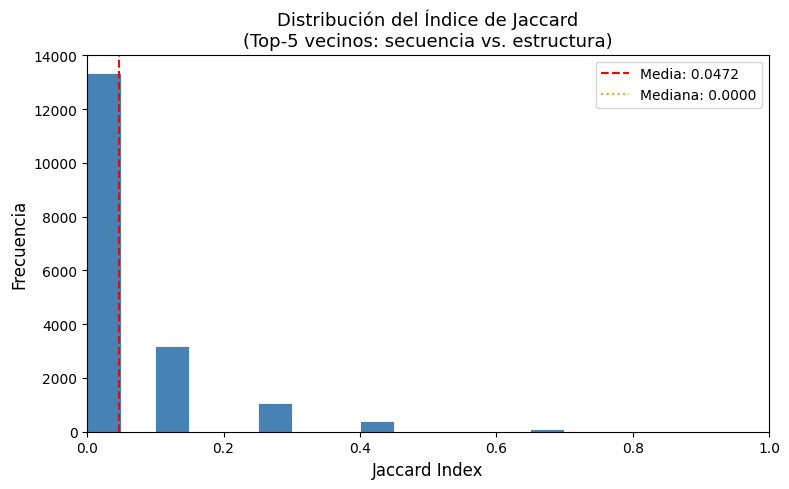

Media:    0.0472
Mediana:  0.0000
Std:      0.1007
Min:      0.0000
Max:      1.0000
% con Jaccard = 0: 73.8%
% con Jaccard = 1: 0.0%


In [4]:

import matplotlib.pyplot as plt
import numpy as np

jaccard_values = result['jaccard_index']

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(jaccard_values, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)

mean_val = jaccard_values.mean()
median_val = jaccard_values.median()
ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Media: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle=':', linewidth=1.5, label=f'Mediana: {median_val:.4f}')

ax.set_xlabel('Jaccard Index', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del Índice de Jaccard\n(Top-5 vecinos: secuencia vs. estructura)', fontsize=13)
ax.legend()
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('jaccard_distribution.png', dpi=150)
plt.show()

print(f"Media:    {mean_val:.4f}")
print(f"Mediana:  {median_val:.4f}")
print(f"Std:      {jaccard_values.std():.4f}")
print(f"Min:      {jaccard_values.min():.4f}")
print(f"Max:      {jaccard_values.max():.4f}")
print(f"% con Jaccard = 0: {(jaccard_values == 0).mean() * 100:.1f}%")
print(f"% con Jaccard = 1: {(jaccard_values == 1).mean() * 100:.1f}%")


In [5]:
import pandas as pd

# Cargar ambos CSVs
df_seq = pd.read_csv('accession_sequence_vecinos_cercanos.csv', sep=';')
df_str = pd.read_csv('BioData_Structure_vecinos_cercanos.csv', sep=';')

# Quedarse solo con el primer vecino (rank == 1) y las columnas de interés
top1_seq = (df_seq[df_seq['rank'] == 1][['uniprot_id', 'neighbor_uniprot_id']]
            .reset_index(drop=True))

top1_str = (df_str[df_str['rank'] == 1][['uniprot_id', 'neighbor_uniprot_id']]
            .reset_index(drop=True))

# Guardar
top1_seq.to_csv('top1_sequence_pairs.csv', index=False)
top1_str.to_csv('top1_structure_pairs.csv', index=False)

print(f"Secuencia  → {len(top1_seq)} pares guardados en top1_sequence_pairs.csv")
print(f"Estructura → {len(top1_str)} pares guardados en top1_structure_pairs.csv")
print()
print("Primeras filas (secuencia):")
print(top1_seq.head())
print()
print("Primeras filas (estructura):")
print(top1_str.head())


Secuencia  → 18084 pares guardados en top1_sequence_pairs.csv
Estructura → 17709 pares guardados en top1_structure_pairs.csv

Primeras filas (secuencia):
    uniprot_id neighbor_uniprot_id
0  ABTIR_ACIB9          TCPB_BRUME
1   ENG1_RHIMI          ENG1_ACET2
2   POLG_ZIKVF           POLG_ZIKV
3  CUTI1_HYPJR         CUTI1_FUSVN
4   HYPD_CLODI          GRE2_ECOLI

Primeras filas (estructura):
    uniprot_id neighbor_uniprot_id
0  14332_ARATH         1433G_HUMAN
1  14336_ARATH         1433G_HUMAN
2  1433B_HUMAN          BMH1_YEAST
3  1433B_MOUSE         1433F_MOUSE
4  1433E_HUMAN         1433G_HUMAN


import pandas as pd

# Cargar el mapeo uniprot_id -> GOA terms (deduplicado por uniprot_id)
goa_df = pd.read_csv('Uniprot_PDB_Chain_GOA.csv', usecols=['uniprot_id', 'all_goa_terms'])
goa_df = goa_df.dropna(subset=['all_goa_terms']).drop_duplicates(subset='uniprot_id').set_index('uniprot_id')

def enrich_pairs(pairs_df):
    df = pairs_df.copy()
    df['goa_terms_query']    = df['uniprot_id'].map(goa_df['all_goa_terms'])
    df['goa_terms_neighbor'] = df['neighbor_uniprot_id'].map(goa_df['all_goa_terms'])
    return df

top1_seq_goa = enrich_pairs(top1_seq)
top1_str_goa = enrich_pairs(top1_str)

top1_seq_goa.to_csv('top1_sequence_pairs_goa.csv', index=False)
top1_str_goa.to_csv('top1_structure_pairs_goa.csv', index=False)

print(f"Secuencia  → {len(top1_seq_goa)} filas guardadas en top1_sequence_pairs_goa.csv")
print(f"Estructura → {len(top1_str_goa)} filas guardadas en top1_structure_pairs_goa.csv")
print()
print(top1_seq_goa.head(3).to_string())


In [6]:
import pandas as pd

# Cargar el mapeo uniprot_id -> GOA terms (deduplicado por uniprot_id)
goa_df = pd.read_csv('Uniprot_PDB_Chain_GOA.csv', usecols=['uniprot_id', 'all_goa_terms'])
goa_df = goa_df.dropna(subset=['all_goa_terms']).drop_duplicates(subset='uniprot_id').set_index('uniprot_id')

def enrich_pairs(pairs_df):
    df = pairs_df.copy()
    df['goa_terms_query']    = df['uniprot_id'].map(goa_df['all_goa_terms'])
    df['goa_terms_neighbor'] = df['neighbor_uniprot_id'].map(goa_df['all_goa_terms'])
    return df

top1_seq_goa = enrich_pairs(top1_seq)
top1_str_goa = enrich_pairs(top1_str)

top1_seq_goa.to_csv('top1_sequence_pairs_goa.csv', index=False)
top1_str_goa.to_csv('top1_structure_pairs_goa.csv', index=False)

print(f"Secuencia  → {len(top1_seq_goa)} filas guardadas en top1_sequence_pairs_goa.csv")
print(f"Estructura → {len(top1_str_goa)} filas guardadas en top1_structure_pairs_goa.csv")
print()
print(top1_seq_goa.head(3).to_string())


Secuencia  → 18084 filas guardadas en top1_sequence_pairs_goa.csv
Estructura → 17709 filas guardadas en top1_structure_pairs_goa.csv

    uniprot_id neighbor_uniprot_id                                 goa_terms_query                                          goa_terms_neighbor
0  ABTIR_ACIB9          TCPB_BRUME                          GO:0003953, GO:0019677                                      GO:0042802, GO:0141028
1   ENG1_RHIMI          ENG1_ACET2                          GO:0000272, GO:0042973  GO:0000272, GO:0000287, GO:0005509, GO:0016151, GO:0042973
2   POLG_ZIKVF           POLG_ZIKV  GO:0005813, GO:0008289, GO:0045824, GO:0060090              GO:0008289, GO:0030430, GO:0030674, GO:0140886


In [15]:
import functools
import re
from pathlib import Path
import pandas as pd
import requests
from pygosemsim import download, graph, similarity, term_set

base_dir = Path('/home/gsandia/Desktop/TFG')

# Ensure GO OBO file is available locally (some installs do not bundle _resources)
obo_path = download.resource_dir / 'go-basic.obo'
if not obo_path.exists() or obo_path.stat().st_size < 1024:
    download.initialize()
    obo_url = 'https://current.geneontology.org/ontology/go-basic.obo'
    headers = {'User-Agent': 'Mozilla/5.0'}
    r = requests.get(obo_url, headers=headers, timeout=120)
    r.raise_for_status()
    with open(obo_path, 'wb') as f:
        f.write(r.content)

# Load GO graph from local OBO file
G = graph.from_obo(obo_path)

def resolve_input_path(*candidates):
    for name in candidates:
        p1 = Path(name)
        p2 = base_dir / name
        if p1.exists():
            return p1
        if p2.exists():
            return p2
    raise FileNotFoundError(f'None of these files were found: {candidates}')

def parse_go_terms(value):
    if pd.isna(value):
        return set()
    # Robust extraction: works with commas, semicolons, spaces, etc.
    return set(re.findall(r'GO:\d{7}', str(value)))

seq_path = resolve_input_path('top1_sequence_pairs_goa.csv', 'sequence_GOA_PAIRS.csv')
print(f'Using sequence file: {seq_path}')

df_seq = pd.read_csv(seq_path)

rows_out = []
none_count = 0
for _, row in df_seq.iterrows():
    uniprot_id_query = row['uniprot_id']
    uniprot_id_neighbor = row['neighbor_uniprot_id']

    goa_terms_query = parse_go_terms(row.get('goa_terms_query'))
    goa_terms_neighbor = parse_go_terms(row.get('goa_terms_neighbor'))

    wang_sim_func = functools.partial(term_set.sim_func, G, similarity.wang)
    sim_score = term_set.sim_bma(goa_terms_query, goa_terms_neighbor, wang_sim_func)
    if sim_score is None:
        sim_score = 0.0
        none_count += 1
    wang_distance = 1 - sim_score

    rows_out.append({
        'uniprot_id': uniprot_id_query,
        'neighbor_uniprot_id': uniprot_id_neighbor,
        'wang_similarity_bma': sim_score,
        'wang_distance': wang_distance,
        'n_terms_query': len(goa_terms_query),
        'n_terms_neighbor': len(goa_terms_neighbor),
    })

results_wang = pd.DataFrame(rows_out)
out_path = base_dir / 'top1_sequence_pairs_wang.csv'
results_wang.to_csv(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Rows with None similarity (set to 0.0): {none_count}')
print(f'Unique similarity values: {results_wang["wang_similarity_bma"].nunique()}')
print(results_wang["wang_similarity_bma"].describe())

format-version: 1.2
Using sequence file: sequence_GOA_PAIRS.csv
Saved: /home/gsandia/Desktop/TFG/top1_sequence_pairs_wang.csv
Rows with None similarity (set to 0.0): 17
Unique similarity values: 949
count    18084.000000
mean         0.432601
std          0.242207
min          0.000000
25%          0.253000
50%          0.435000
75%          0.596000
max          1.000000
Name: wang_similarity_bma, dtype: float64


In [16]:
# Wang similarity for structure pairs
import functools
import re
from pathlib import Path
import pandas as pd
from pygosemsim import similarity, term_set

base_dir = Path('/home/gsandia/Desktop/TFG')

# Reuse loaded GO graph (G) from previous cell
if 'G' not in globals():
    raise RuntimeError("Run the previous Wang cell first to load GO graph into variable 'G'.")

def resolve_input_path(*candidates):
    for name in candidates:
        p1 = Path(name)
        p2 = base_dir / name
        if p1.exists():
            return p1
        if p2.exists():
            return p2
    raise FileNotFoundError(f'None of these files were found: {candidates}')

def parse_go_terms(value):
    if pd.isna(value):
        return set()
    return set(re.findall(r'GO:\d{7}', str(value)))

str_path = resolve_input_path(
    'top1_structure_pairs_goa.csv',
    'Structure_GOA_Pairs.csv',
    'structure_GOA_PAIRS.csv'
)
print(f'Using structure file: {str_path}')

df_str = pd.read_csv(str_path)

rows_out = []
none_count = 0
for _, row in df_str.iterrows():
    uniprot_id_query = row['uniprot_id']
    uniprot_id_neighbor = row['neighbor_uniprot_id']

    goa_terms_query = parse_go_terms(row.get('goa_terms_query'))
    goa_terms_neighbor = parse_go_terms(row.get('goa_terms_neighbor'))

    wang_sim_func = functools.partial(term_set.sim_func, G, similarity.wang)
    sim_score = term_set.sim_bma(goa_terms_query, goa_terms_neighbor, wang_sim_func)
    if sim_score is None:
        sim_score = 0.0
        none_count += 1
    wang_distance = 1 - sim_score

    rows_out.append({
        'uniprot_id': uniprot_id_query,
        'neighbor_uniprot_id': uniprot_id_neighbor,
        'wang_similarity_bma': sim_score,
        'wang_distance': wang_distance,
        'n_terms_query': len(goa_terms_query),
        'n_terms_neighbor': len(goa_terms_neighbor),
    })

results_wang_structure = pd.DataFrame(rows_out)
out_path_structure = base_dir / 'top1_structure_pairs_wang.csv'
results_wang_structure.to_csv(out_path_structure, index=False)

print(f'Saved: {out_path_structure}')
print(f'Rows with None similarity (set to 0.0): {none_count}')
print(f'Unique similarity values: {results_wang_structure["wang_similarity_bma"].nunique()}')
print(results_wang_structure["wang_similarity_bma"].describe())

Using structure file: Structure_GOA_Pairs.csv
Saved: /home/gsandia/Desktop/TFG/top1_structure_pairs_wang.csv
Rows with None similarity (set to 0.0): 9
Unique similarity values: 857
count    17709.000000
mean         0.268382
std          0.196461
min          0.000000
25%          0.119000
50%          0.235000
75%          0.375000
max          1.000000
Name: wang_similarity_bma, dtype: float64


In [ ]:
# Dispersión comparativa: sequence vs structure (Wang similarity)
import pandas as pd
import matplotlib.pyplot as plt

seq_file = '/home/gsandia/Desktop/TFG/top1_sequence_pairs_wang.csv'
str_file = '/home/gsandia/Desktop/TFG/top1_structure_pairs_wang.csv'

seq_df = pd.read_csv(seq_file)
str_df = pd.read_csv(str_file)

seq_vals = seq_df['wang_similarity_bma'].dropna()
str_vals = str_df['wang_similarity_bma'].dropna()

def dispersion_stats(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        'n': int(series.shape[0]),
        'mean': float(series.mean()),
        'std': float(series.std()),
        'var': float(series.var()),
        'iqr': float(q3 - q1),
        'min': float(series.min()),
        'max': float(series.max()),
    }

stats_seq = dispersion_stats(seq_vals)
stats_str = dispersion_stats(str_vals)

summary = pd.DataFrame([stats_seq, stats_str], index=['sequence', 'structure'])
print('Resumen de dispersion (Wang similarity):')
print(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma superpuesto
axes[0].hist(seq_vals, bins=40, alpha=0.55, label='Sequence', color='teal', edgecolor='white')
axes[0].hist(str_vals, bins=40, alpha=0.55, label='Structure', color='tomato', edgecolor='white')
axes[0].set_title('Distribucion de Wang Similarity')
axes[0].set_xlabel('wang_similarity_bma')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].set_xlim(0, 1)

# Boxplot comparativo (dispersión)
axes[1].boxplot([seq_vals, str_vals], labels=['Sequence', 'Structure'], patch_artist=True,
                boxprops=dict(facecolor='#d9f2f2'), medianprops=dict(color='black'))
axes[1].set_title('Boxplot de dispersion')
axes[1].set_ylabel('wang_similarity_bma')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/home/gsandia/Desktop/TFG/wang_dispersion_comparison.png', dpi=180)
plt.show()

print('\nGrafica guardada en: /home/gsandia/Desktop/TFG/wang_dispersion_comparison.png')